<a href="https://colab.research.google.com/github/abisolami/industries-ai-usage/blob/main/Industries_ai_usage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AI TOOL ADOPTION ACROSS VARIOUS INDUSTRY**

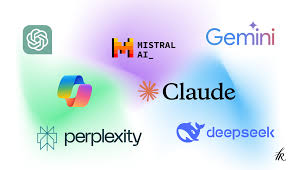

**Aim**

The dataset contains information about usage of AI tools (ChatGPT, Claude...) across industry throughout the year 2023 and 2024.

The primary aim of this project is to accurately predict the adoption rate of various AI tool and industry within a specific year in a country


In [29]:
# Importing libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



## **Data Overview**


In [30]:
# Dataset can be found in my google drive
url = "https://docs.google.com/spreadsheets/d/1EJr19S8K5r-gQKOiVqQL5oLYGmeZzmvBNF7NckqMdmk/export?format=csv"

# reading the dataset
data = pd.read_csv(url)
data.head()

,country,industry,ai_tool,adoption_rate,daily_active_users,year,user_feedback,age_group,company_size
0,USA,Technology,ChatGPT,40.45,2461,2023,YyvLXOFyevRMSvJtkXodLvgejiqQNvSOZfeeJASDOVTxwm...,35-44,Startup
1,France,Manufacturing,Midjourney,35.72,8496,2024,AdFVhenjthYSKJNzxzfaGQk wLnjRCgrHTyfXQEFjFJCMO...,18-24,Enterprise
2,Australia,Transportation,ChatGPT,13.47,8641,2024,zgNPmXBICRNbpjpTqIUWmMTeTYsInDNtAmzuxpDvcUZEAi...,45-54,Startup
3,UK,Manufacturing,ChatGPT,48.46,3488,2023,LxeKzQFbPvhxXUSgPVlLLJ pUFaicjCgiMtAmsTjovkrdE...,45-54,Enterprise
4,UK,Agriculture,Stable Diffusion,34.06,1124,2024,IOQtQoSKdSmiXRsUKpjXjXZgQohymFkVUvOASXlEnVsIOS...,45-54,SME


*The table above shows the first few feilds of the dataset*

For more information about the dataset

In [31]:
# data info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145000 entries, 0 to 144999
Data columns (total 9 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   country             145000 non-null  object 
 1   industry            145000 non-null  object 
 2   ai_tool             145000 non-null  object 
 3   adoption_rate       145000 non-null  float64
 4   daily_active_users  145000 non-null  int64  
 5   year                145000 non-null  int64  
 6   user_feedback       145000 non-null  object 
 7   age_group           145000 non-null  object 
 8   company_size        145000 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 10.0+ MB


**Understanding the Dataset**

In [32]:
# verifying the shape of the dataset

print(f"The Dataset has {data.shape[0]} Rows and {data.shape[1]} Columns\n")

print(f"The {data.shape[1]} features in the dataset are: \n{data.columns.tolist()}")

The Dataset has 145000 Rows and 9 Columns

The 9 features in the dataset are: 
['country', 'industry', 'ai_tool', 'adoption_rate', 'daily_active_users', 'year', 'user_feedback', 'age_group', 'company_size']


Before we move on, Lets analyze these features

---
---

The dataset has over 100K instances with features including:



*  **Country**: Country where the organization or user is located (e.g., USA, India, China, etc.)

*  **Industry**: Industry sector of the organization (e.g., Technology, Healthcare, Retail, etc.)

*  **AI_tool**: Name of the AI tool used (e.g., ChatGPT, Midjourney, Bard, Stable Diffusion, Claude)

*  **Adoption_rate**: Percentage representing the adoption rate of the AI tool within the sector or company (0–100)       
*  **Daily_active_users**:  Estimated number of daily active users for the AI tool in the given context  
*  **Year**: Year in which the data was recorded (2023 or 2024)         
*  **User_feedback**: 	Free-text feedback from users about their experience with the AI tool (up to 150 characters)        
*  **Age_group**: Age group of users (e.g., 18-24, 25-34, 35-44, 45-54, 55+)         
*  **Company_size:** Size category of the organization (Startup, SME, Enterprise)








## **Data Cleaning**

Getting rid of all Null and duplicate values to ensure the dataset is ready for further exploration

In [33]:
# Checking NaN values
data.isna().sum()

,0
country,0
industry,0
ai_tool,0
adoption_rate,0
daily_active_users,0
year,0
user_feedback,0
age_group,0
company_size,0


In [34]:
# checking for duplicat values
data.duplicated().sum()

np.int64(0)

*It seems like the data is not as messy. There are no missing or duplicated values in the datasets.*

**Feature Removal**

The ***'User Feedback'*** feature would be dropped/removed as it adds no value to the analysis and model development.

In [35]:
# removing the user feedback column in the dataset
data = data.drop(['user_feedback'], axis=1)
data.head()

,country,industry,ai_tool,adoption_rate,daily_active_users,year,age_group,company_size
0,USA,Technology,ChatGPT,40.45,2461,2023,35-44,Startup
1,France,Manufacturing,Midjourney,35.72,8496,2024,18-24,Enterprise
2,Australia,Transportation,ChatGPT,13.47,8641,2024,45-54,Startup
3,UK,Manufacturing,ChatGPT,48.46,3488,2023,45-54,Enterprise
4,UK,Agriculture,Stable Diffusion,34.06,1124,2024,45-54,SME


**Data Conversion**

In [36]:
data.dtypes

,0
country,object
industry,object
ai_tool,object
adoption_rate,float64
daily_active_users,int64
year,int64
age_group,object
company_size,object


**General Observation**

* There is a total of 145000
observation and 9 features in the dataset
* The dataset contained no missing values and no duplicate values
* The User Feedback was dropped as it has no significant value to the exploration

## **Data Exploration**

**Deriving the Distinct values for each of the features**


In [37]:
# unique values of each features

features = ['country', 'industry', 'ai_tool', 'year', 'age_group', 'company_size']

for feature in features:
  print(f"{feature}\nThere are {data[feature].nunique()} distinct values here, which are:")
  print(f"{data[feature].unique().tolist()}\n\n")

country
There are 10 distinct values here, which are:
['USA', 'France', 'Australia', 'UK', 'Brazil', 'China', 'Canada', 'South Korea', 'India', 'Germany']


industry
There are 8 distinct values here, which are:
['Technology', 'Manufacturing', 'Transportation', 'Agriculture', 'Education', 'Healthcare', 'Retail', 'Finance']


ai_tool
There are 5 distinct values here, which are:
['ChatGPT', 'Midjourney', 'Stable Diffusion', 'Bard', 'Claude']


year
There are 2 distinct values here, which are:
[2023, 2024]


age_group
There are 5 distinct values here, which are:
['35-44', '18-24', '45-54', '55+', '25-34']


company_size
There are 3 distinct values here, which are:
['Startup', 'Enterprise', 'SME']




*The dataset is not just clean but it has been made easy to categorize and visualize easily.*

**Value counts for each feature**


In [38]:
# counting the number of instances for each classes in the dataset

for feature in features:
  print(f"For the {data[feature].value_counts()}\n\n")

For the country
Australia      14723
France         14676
China          14562
South Korea    14540
India          14531
UK             14476
Germany        14405
Brazil         14381
Canada         14354
USA            14352
Name: count, dtype: int64


For the industry
Manufacturing     18267
Education         18200
Transportation    18158
Technology        18134
Finance           18124
Healthcare        18118
Retail            18053
Agriculture       17946
Name: count, dtype: int64


For the ai_tool
ChatGPT             58045
Midjourney          43324
Stable Diffusion    21826
Bard                14519
Claude               7286
Name: count, dtype: int64


For the year
2024    101952
2023     43048
Name: count, dtype: int64


For the age_group
55+      29424
25-34    29061
35-44    28873
45-54    28833
18-24    28809
Name: count, dtype: int64


For the company_size
Startup       48601
Enterprise    48279
SME           48120
Name: count, dtype: int64




*With this, you can easily tell 2024 recorded the most AI usage across various industries*


*Notice how balanced the **Country** class is?
As well as the ***Industry***, **Company-size**and the **age-group***

### **Target Variable Analysis**

Based on my discretion, I would select the adoption_rate as my target variable. That automatically makes this a regression problem

In [39]:
# printing samples of the target variable
data['adoption_rate'].tail(7)

,adoption_rate
144993,85.08
144994,88.81
144995,86.93
144996,51.99
144997,47.35
144998,31.87
144999,96.84


In [40]:
# exploring the target variable
print(f"The highest percentage adoption rate of AI tools within an industry is {data['adoption_rate'].max()}%")
print(f"While the lowest percentage adoption rate of AI tools across various industry is {data['adoption_rate'].min()}%\n\n")

# for further description
data['adoption_rate'].describe()

The highest percentage adoption rate of AI tools within an industry is 100.0%
While the lowest percentage adoption rate of AI tools across various industry is 0.0%




,adoption_rate
count,145000.000000
mean,49.873025
std,28.842523
min,0.000000
25%,24.930000
50%,49.760000
75%,74.840000
max,100.000000


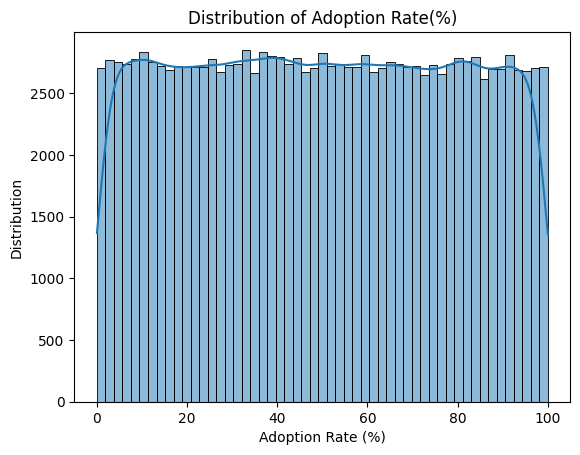

In [41]:
# checking for skewness of the target variable

plt.figure.figsize=(10,6)
sns.histplot(data['adoption_rate'], kde=True)
plt.title("Distribution of Adoption Rate(%)")
plt.xlabel("Adoption Rate (%)")
plt.ylabel("Distribution")
plt.show()

*This shows a uniform distribution, that is all possible values occurs with roughly the same frequency in the dataset*

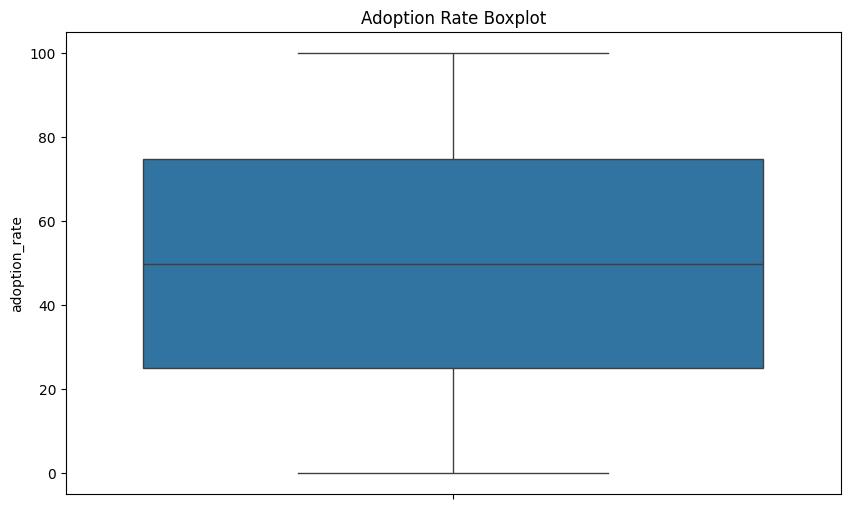

In [42]:
# visualizing the adoption_rate to check for outliers
plt.figure(figsize=(10,6))
sns.boxplot(data['adoption_rate'])
plt.title("Adoption Rate Boxplot")
plt.show()

The boxplot clearly shows they are no outliers in the dataset, indicating its readiness for model training


**General Observation**

* The target variable ranges from 0% to 100%
* ***Adoption rate*** is uniformly distributed, which tend to have little to no correlation with other feature
* The boxplot shows the absense of outliers in the dataset

All of which is not normal for real world data

## **Data visualization**



**Visualizing the Yearly distribution**

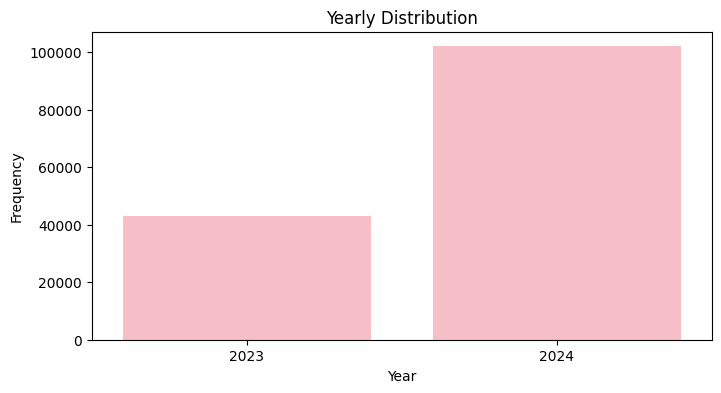

In [43]:
# yearly distribution
plt.figure(figsize=(8,4))
sns.countplot(data, x='year', color='lightpink')
plt.title("Yearly Distribution")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()

**Observation**: As mentioned before, 2024 recorded the most **AI adoption** across all ***industries*** in this datasets with over 100k entries. Year 2023 only recorded 40k

**Determining the most used AI Tools yearly**

/tmp/ipykernel_13797/3266935011.py:4: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:lightgreen'` for the same effect.

  sns.countplot(data, x='ai_tool', hue='year', color='lightgreen')


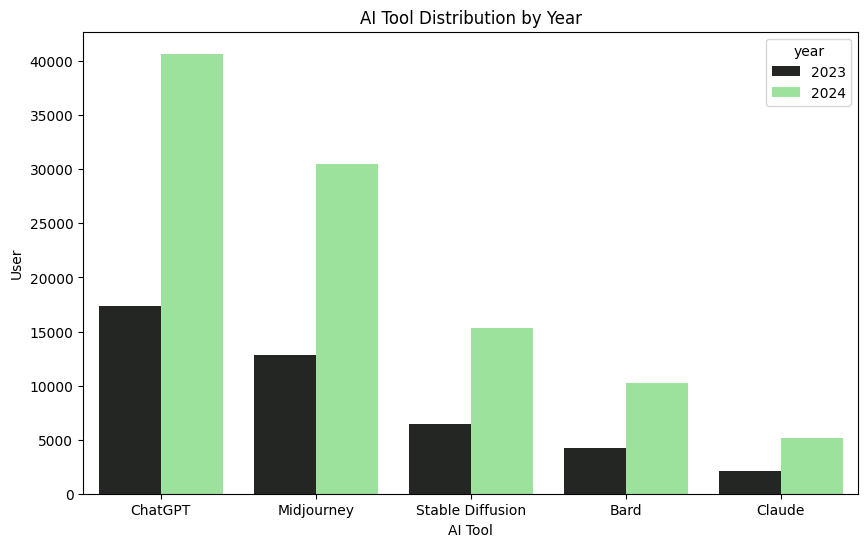

In [44]:
# visualing the ai tools adopted each year

plt.figure(figsize=(10, 6))
sns.countplot(data, x='ai_tool', hue='year', color='lightgreen')
plt.title("AI Tool Distribution by Year")
plt.xlabel("AI Tool")
plt.ylabel("User")
plt.show()

**Observation**

The visualization above simply shows the specific ***AI tools*** that were used the most within the year (2023 and 2024)


*ChatGPT* had over 40k users in 2024 but about 17k in 2023, which is over 100% increase in the number of users.

*Midjourney* and *Stable Diffusion* happens to be used as well, with a significant number of increase in the following year 2024.

Whereas, *Bard* and *Claude* were the least used ***AI tools*** in 2023 with not so much dramatic change in the number of users the following year 2024

**Visualizing the AI tools mostly used in specific country**

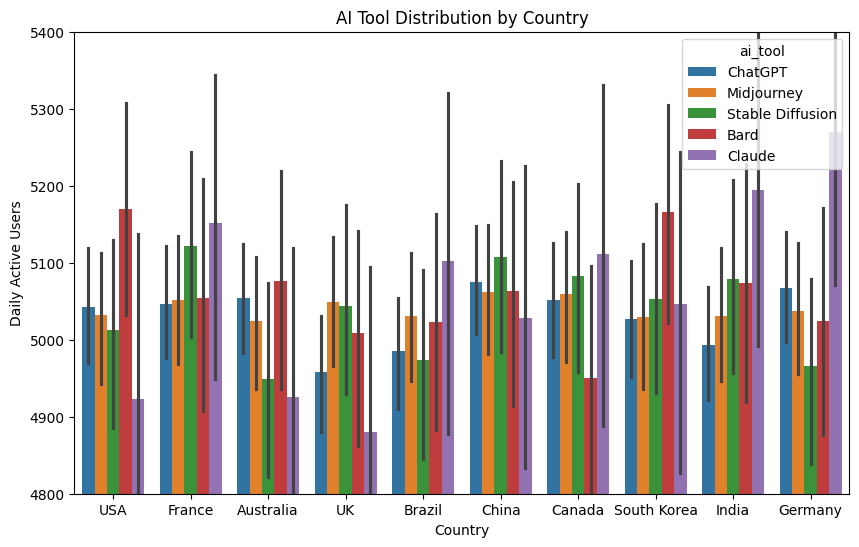

In [45]:
# visualing the ai tools mostly used in specific countries based on their daily users

plt.figure(figsize=(10, 6))
sns.barplot(x='country', y='daily_active_users', data=data, hue='ai_tool')
plt.title("AI Tool Distribution by Country")
plt.xlabel("Country")
plt.ylabel("Daily Active Users")
plt.ylim(4800,5400)
plt.show()

**Observation**

The chart compares daily active users of different ***AI tools*** across countries

* **Chat GPT**: very consistent across almost all countries like (***USA, France, Australia, Canada, and Germany***) and sligtly dips in India. It is not always the highest but always present

*  **Midjourney**: This AI tool is slightly utilized in countries like ***UK, Canada, and India*** but not in countries like ***Australia and Germany***. It is also not dominating in any country

*  **Stable Diffusion**: This tool has higher usage in ***France, China and Canada*** but lower in ***Australia and Germany***. it is not evely adoptoped

*  **Bard**: It is the most inconsistent AI tool. it has more usage in ***USA and South Korea*** but drops in ***UK, Canada and Germany***

* **Claude**: It has the most interesting pattern. It highest peak in the chart is in ***India and Germany***, also strong in ***France and Canada*** but slightly lower in ***USA, Australia and UK***

---
***The Global adoption of AI seems to be relatively even, no country dramatically behind or ahead***



**Visualizing the highest AI tool adoption rate across all countries**

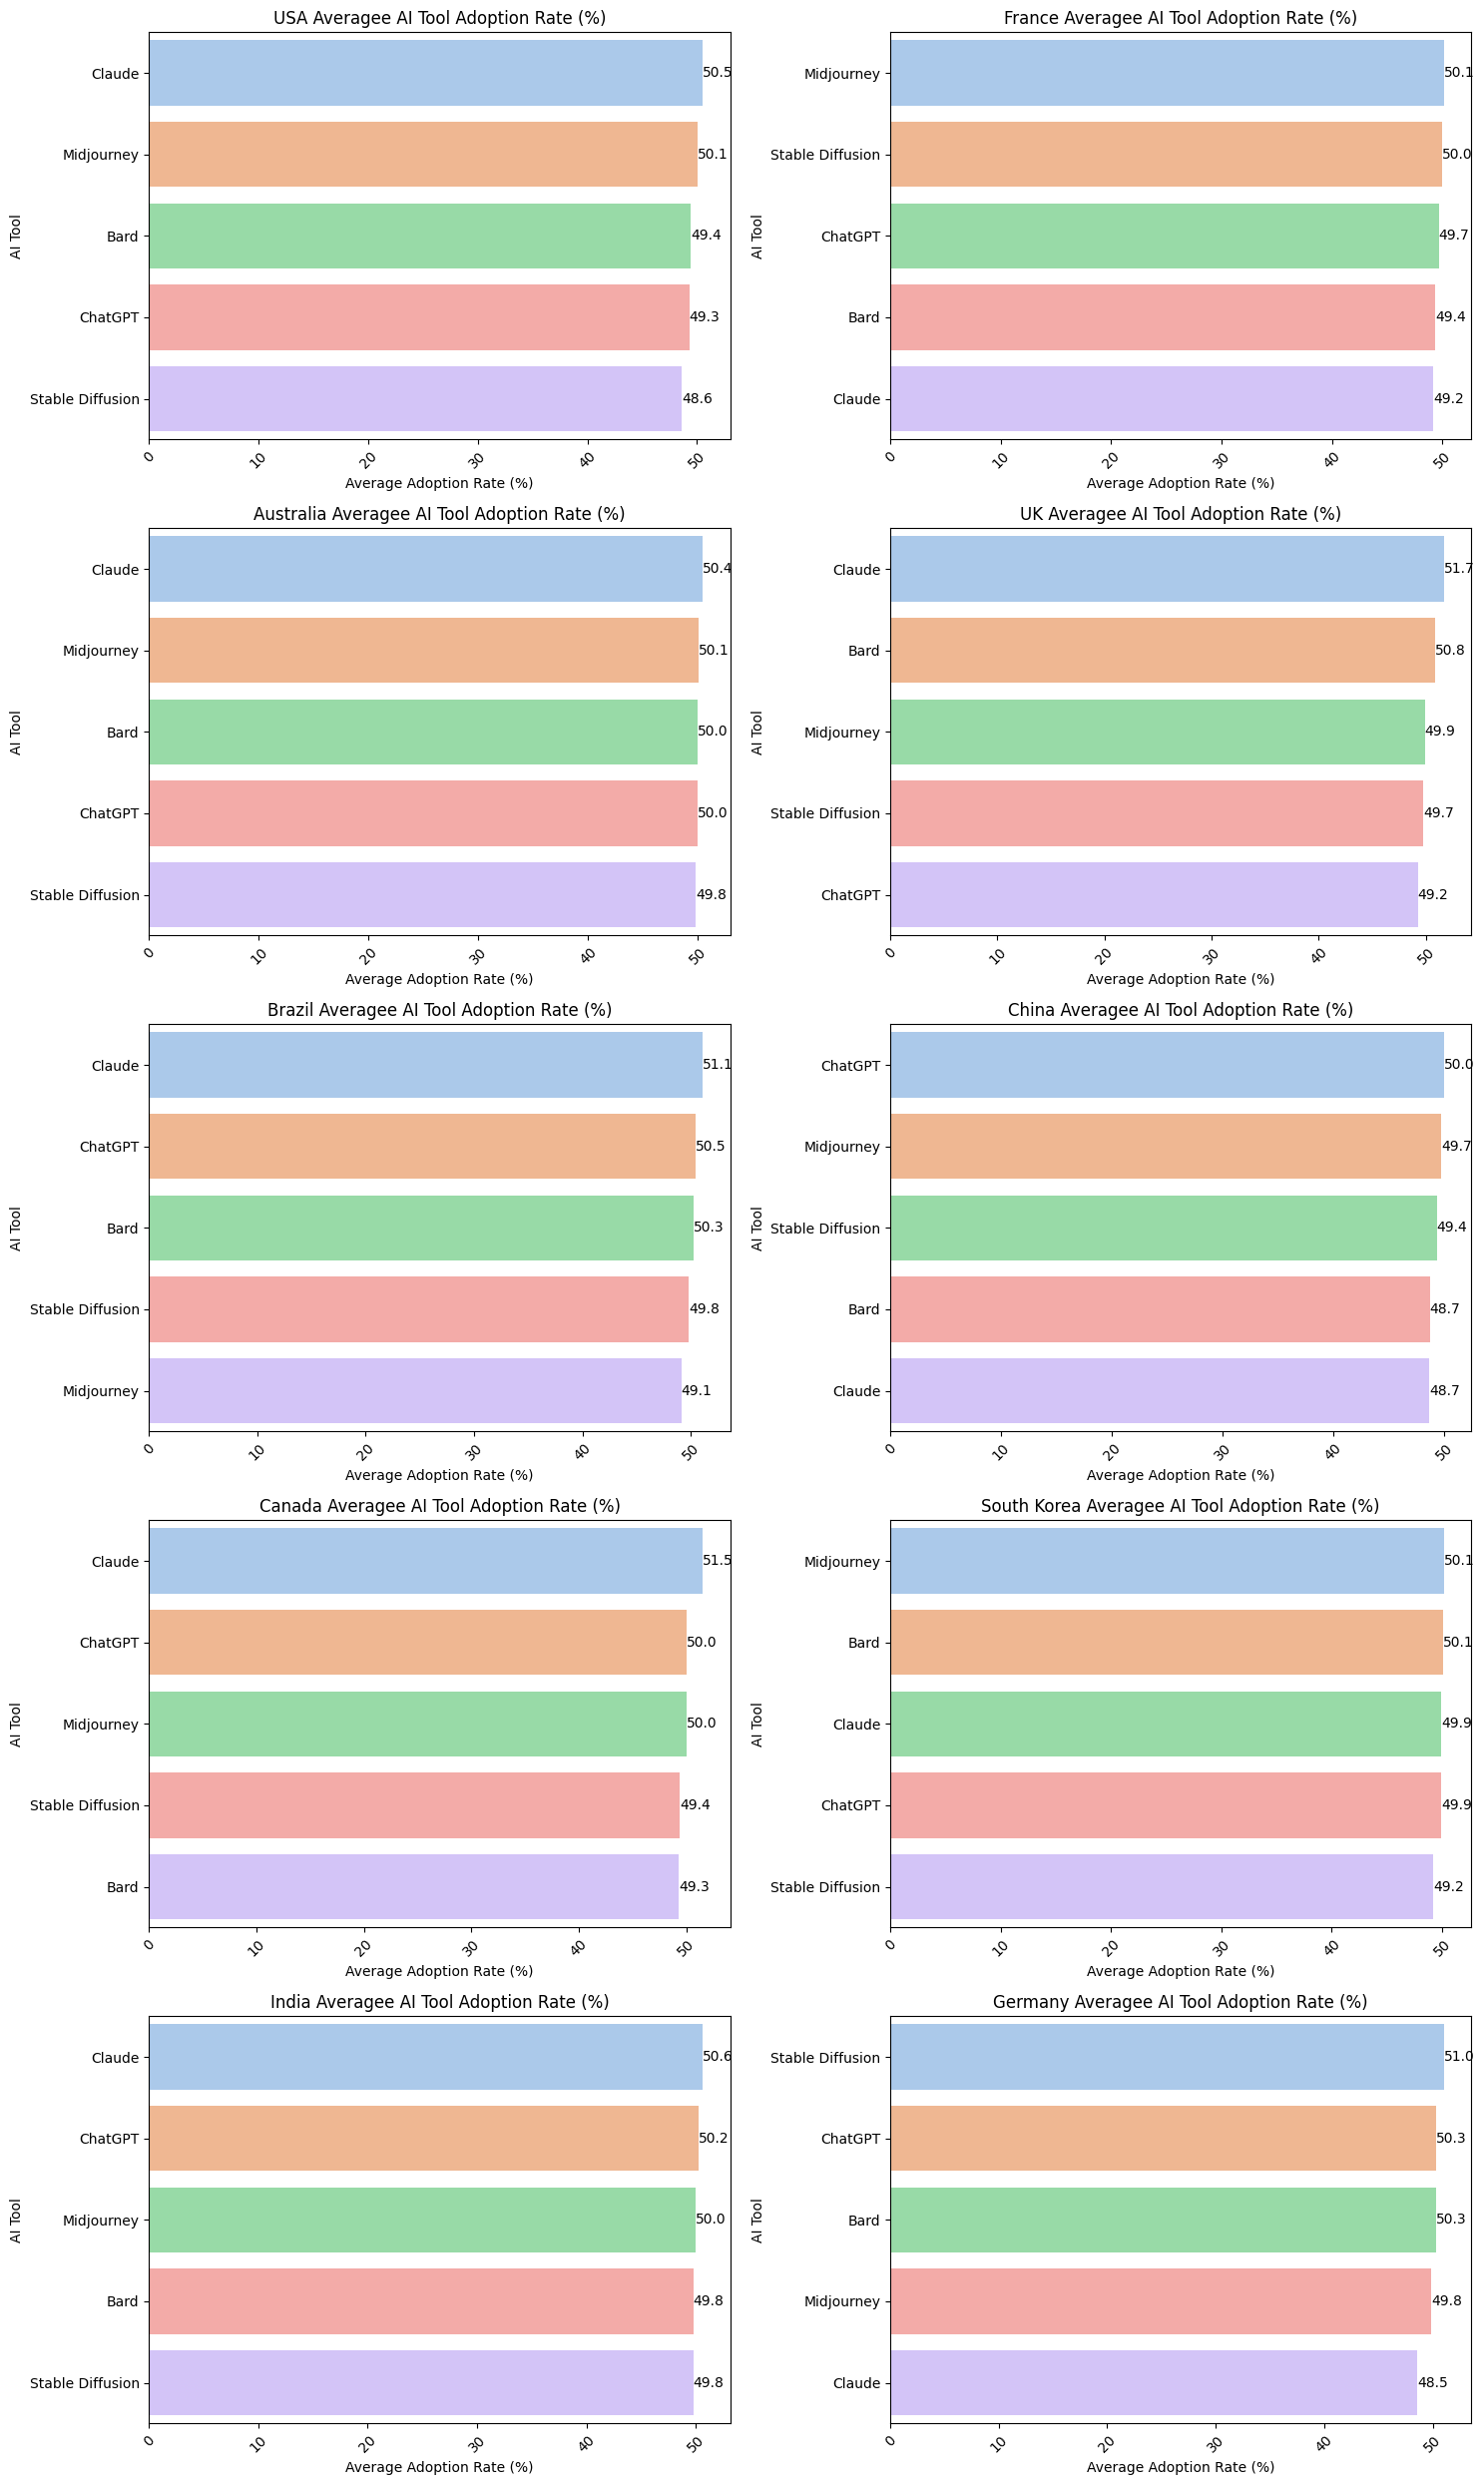

In [46]:
# Visualizing the highest AI tool average adoption rate across all countries

# grouping the dataset into country, AI tool and the mean adoption rate
country_adoption_rate = data.groupby(['country', 'ai_tool'])['adoption_rate'].mean().reset_index()
# sorting the adoption rate in descending order
country_adoption_rate.sort_values(by='adoption_rate', ascending=False, inplace=True)

# defining unique country in the dataset again
unique_country = data['country'].unique()


# plotting in rows (5) and columns (2)
fig, axes = plt.subplots(5, 2, figsize=(15,25))

axes = axes.flatten()

for axe, country in zip(axes, unique_country):
  country_data = country_adoption_rate[country_adoption_rate['country'] == country] #to derive the country information

  # plotting
  sns.barplot(y='ai_tool', x='adoption_rate', data=country_data, palette='pastel', hue='ai_tool', legend=False, ax=axe)
  axe.set_title(f'{country} Averagee AI Tool Adoption Rate (%)')
  axe.set_xlabel('Average Adoption Rate (%)')
  axe.set_ylabel('AI Tool')
  axe.tick_params(axis='x', rotation=45)

# to show the exact figure at the top of each bin
  for container in axe.containers:
    axe.bar_label(container, fmt='%.1f')

plt.tight_layout()
plt.show()

**Observation**

All AI tool had very similar adoption rate across all countries but heres a slight difference.

Based on the visualization above, Claude AI Tool has the most adoption rate in most countries like ***USA, Australia, UK, Brazil, Canada and India*** with over 50% **Adoption Rate**

Stable Diffusion AI tool had the least adopotin rate in about 4 countries (***USA, Australia, South Korea and India***)

**Visualizing AI tool with Most Daily Active User Yearly**

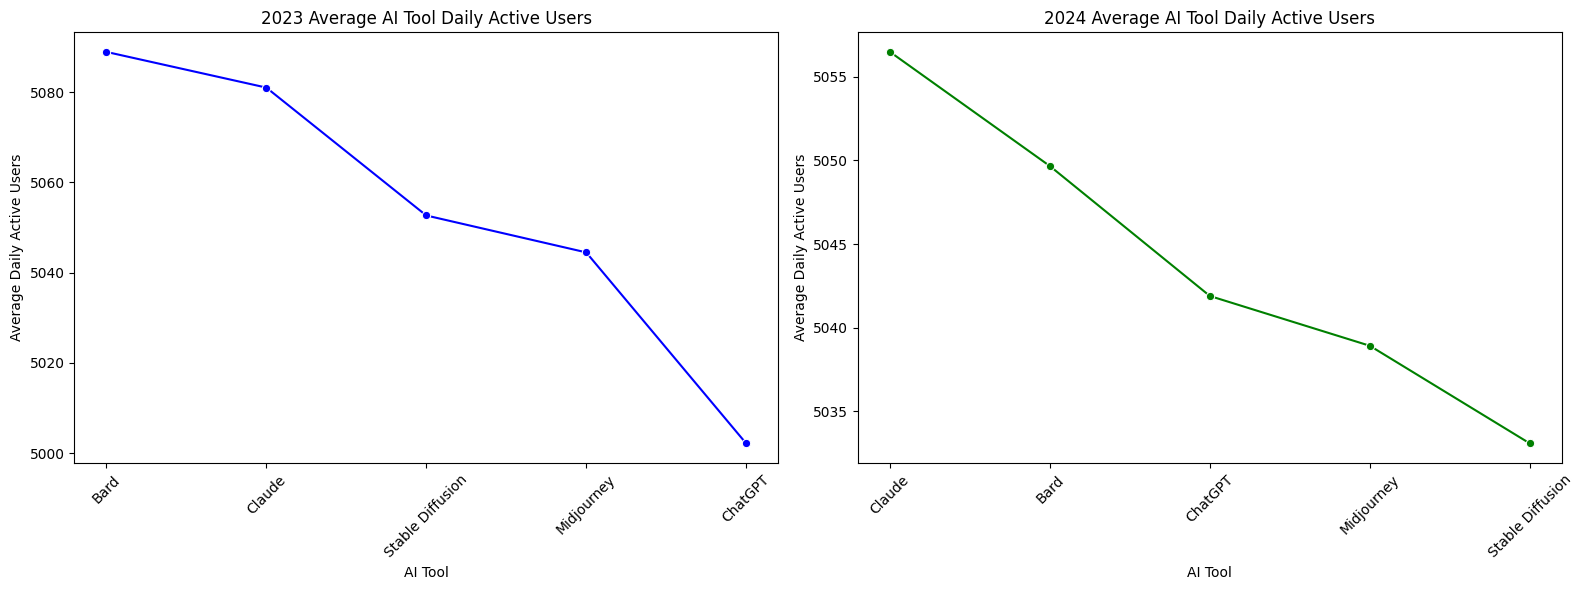

In [47]:
#visualizing AI tool with highest daily active user over the year

# groupy the average number of daily active user for each ai tool
yearly_daily_active = data.groupby(['year', 'ai_tool'])['daily_active_users'].mean().reset_index()
# in descending format
yearly_daily_active.sort_values(by='daily_active_users', ascending=False, inplace=True)

# defining unique year
unique_year = data['year'].unique()

# define colors for the plots
plot_colors = ['blue', 'green'] # Using distinct colors for each year's line plot

# subplot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# plotting
for i, year in enumerate(unique_year):
  current_ax = axes[i] # Get the current subplot axis
  year_data = yearly_daily_active[yearly_daily_active['year'] == year]
  sns.lineplot(x='ai_tool', y='daily_active_users', data=year_data, marker='o', color=plot_colors[i], ax=current_ax)
  current_ax.set_title(f'{year} Average AI Tool Daily Active Users') # Corrected from ax.title
  current_ax.set_xlabel('AI Tool')
  current_ax.set_ylabel('Average Daily Active Users')
  current_ax.tick_params(axis='x', rotation=45)

plt.tight_layout() #prevent overlapping
plt.show()

**Obervation**

The Line chart displays the **Average daily active user for each AI tool within the year 2023 and 2024**. All AI tool have an average daily user of 5000, but if we decide to read between the lines...

It show **Bard** had the most average daily users as at 2023 and **ChatGPT** with the least.

While in year 2024, **Claude** had the highest average daily user and **Stable Diffusion** dropped in that same year

**Visualizing the Average Adoption Rate of each AI Tool Across all Age Group**

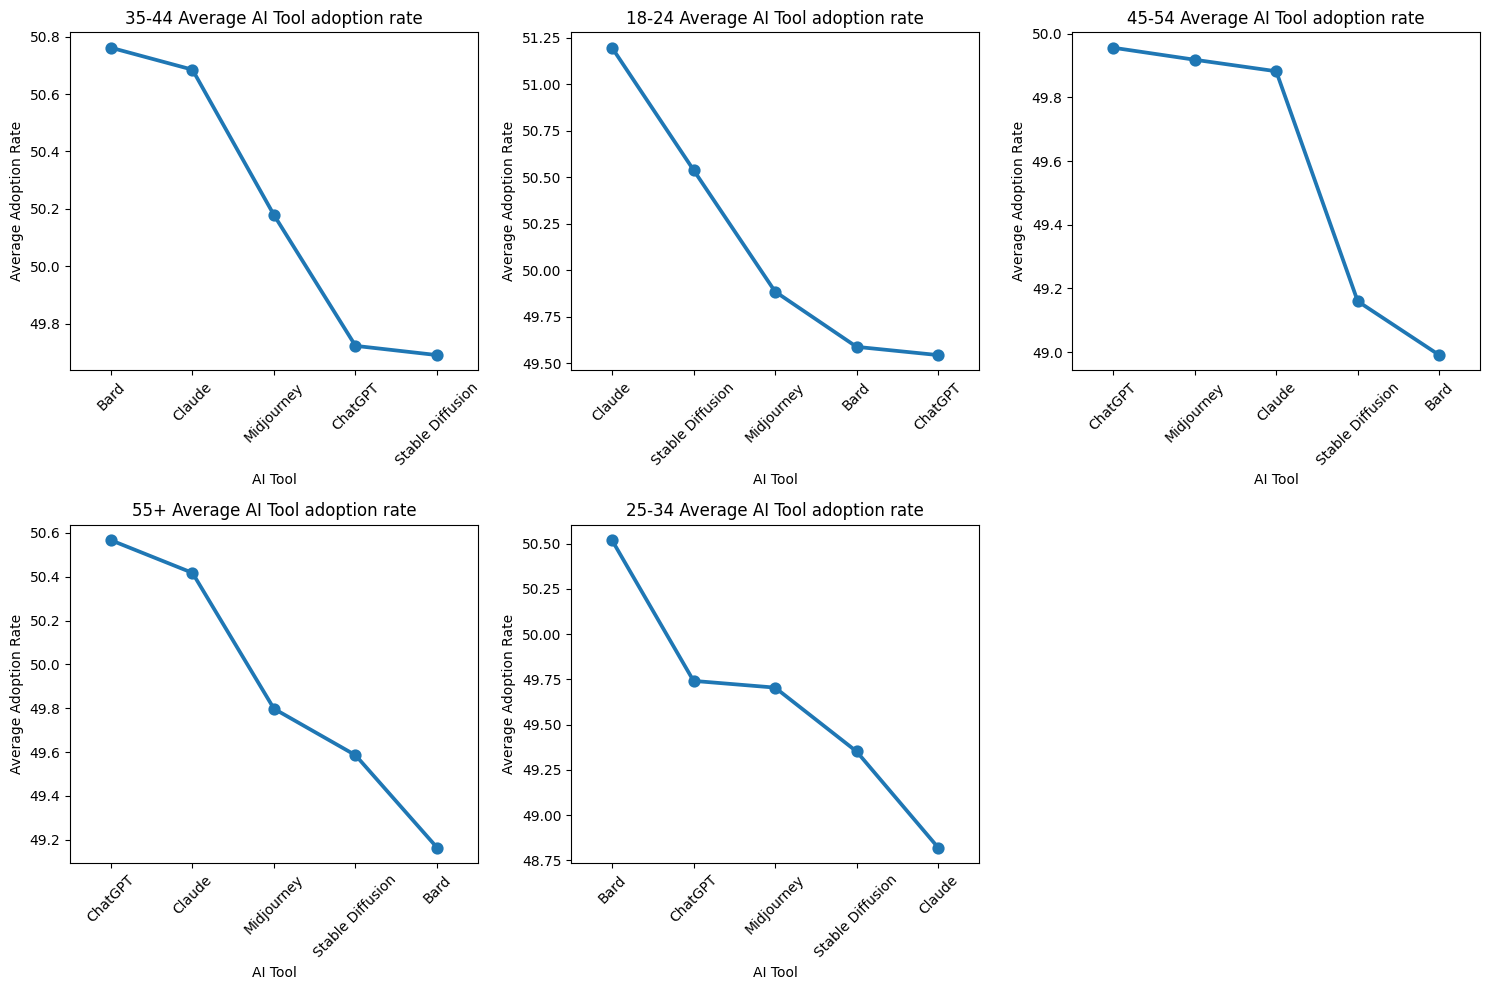

In [48]:
# line plot of age group with average adoptio rate
age_group_daily_active = data.groupby(['age_group', 'ai_tool'])['adoption_rate'].mean().reset_index()
age_group_daily_active.sort_values(by='adoption_rate', ascending=False, inplace=True)

# creating suplot for each age group
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten() # Flatten the 2x3 array of axes into a 1D array

unique_age_group = data['age_group'].unique()

# iterating over each age groups
for i, age_group in enumerate(unique_age_group):
  ax = axes[i] # Get the current subplot axis
  age_group_data = age_group_daily_active[age_group_daily_active['age_group'] == age_group]
  sns.pointplot(x='ai_tool', y='adoption_rate', data=age_group_data, ax=ax) # Changed to pointplot
  ax.set_title(f'{age_group} Average AI Tool adoption rate')
  ax.set_xlabel('AI Tool')
  ax.set_ylabel('Average Adoption Rate')
  ax.tick_params(axis='x', rotation=45)

# Hide any unused subplots if there are fewer age groups than subplots (e.g., 5 groups, 6 subplots)
for j in range(len(unique_age_group), len(axes)):
  fig.delaxes(axes[j]) # Remove unused subplot

plt.tight_layout() # Adjust layout to prevent titles/labels from overlapping
plt.show() # Display the single figure with all subplots

**Observation**

***Age Group***

**18-24**: adopted the use of **Claude and Stable Diffusion** on an average to **ChatGPT**

**25-34**: Seem to have adopted the use of **Bard and ChatGPT** compared to **Claude**

**35-44**: Have higher average adoption rate with **Bard and Claude** AI compared to **ChatGPT and Stable Diffusion**

**45-54**: This age group use more **ChatGPT and Midjourney** on a average.

While Users of year **55+** use **Claude and ChatGPT** as it has the highest average adoption rate

**Visualizing AI tools used daily based on Company Size**

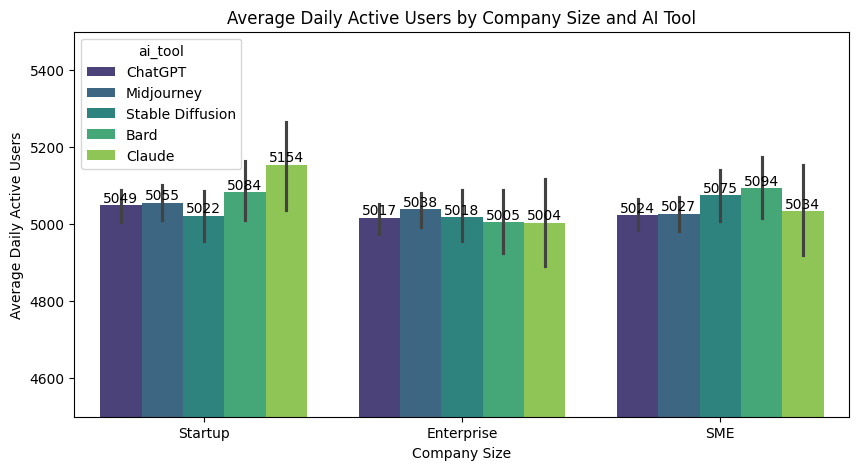

In [49]:
# company size ai tool
plt.figure(figsize=(10, 5))
ax = sns.barplot(x='company_size', y='daily_active_users', hue='ai_tool', data=data, palette='viridis')
plt.title('Average Daily Active Users by Company Size and AI Tool')
plt.xlabel('Company Size')
plt.ylabel('Average Daily Active Users')

# Set y-axis limits for zooming
plt.ylim(4500, 5500) # Zoom to show 4000-5000 range

# Add actual numbers on top of the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f') # integer values

plt.show()

**Observation**

The charts compares how different **Company Sizes** use various AI tools based on average **Daily Active Users**.

***Startup*** shows the highes engagement overall with AI tools like **Claude and Bard**.
 This shows how startup are more willing to experiment with AI Tools.

***Enterprise*** All AI tools here are almost at the same level, no signficant difference.
Enterprises are more balanced cautious, they dont have any preference as they are using all the tools equally.


***SMEs(Small and Medium Enterprise)*** Here **Claude** dropped  compared to startup. While **Bard** and **Stable Diffusion** are slightly higher than the other.

## **Feature Engineering**

In [58]:
# Dividing the data into categorical and numerical dataset
categorical_data = data.select_dtypes(include='object').columns
categorical_data

Index(['country', 'industry', 'ai_tool', 'age_group', 'company_size'], dtype='object')

In [59]:
numerical_data = data.select_dtypes(include=np.number).columns
numerical_data

Index(['adoption_rate', 'daily_active_users', 'year'], dtype='object')

In [61]:
# how do i scale the categorical data
